In [7]:
library(sp)
library(terra)
library(tidyverse)
library(sf)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks terra::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [10]:
source('/projects/code/3dsi/boreal_map_functions.R')


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


The following object is masked from ‘package:terra’:

    shift



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


The following object is masked from ‘package:terra’:

    rescale




In [11]:
crs_canalb

[1] "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"

In [8]:
# ##### packages
# require(pacman)
# #p_load(raster, rgdal,rgee,tidyverse,sf, rnaturalearth, fs)
# p_load(raster, rgdal,rgee,tidyverse,sf, rnaturalearth, fs)

In [3]:
gridCreate<-function(shp, res, proj_out, buffer=10000){
  
  if (!is.null(buffer)){
    shp<-buffer(shp, width=buffer)
  }
  ext <- floor(extent(shp))
  rr <- raster(ext, res=res)
  rr <- rasterize(shp, rr, field=1)
  rr[!is.na(rr[])]<-1:length(rr[!is.na(rr[])])
  grid<-rasterToPolygons(rr)
  crs(grid)<-projection(shp)
  if (!proj_out==projection(shp)){
    grid<-spTransform(grid,CRS(proj_out))
  }
  return(grid)  
}

make_boreal_grid_file <- function(boreal_shp_fn=wwf_circ_dis_fn, tile_size_km=90, out_dir = "D:\\databank", 
                                 #out_crs = "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
                                 out_crs = '+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs'
                                 ){
  
  # ##### packages
  # require(pacman)
  # #p_load(raster, rgdal,rgee,tidyverse,sf, rnaturalearth, fs)
  # p_load(raster, rgdal,rgee,tidyverse,sf, rnaturalearth, fs)
  
  
  ##### data
  world <- ne_countries(scale = "medium", returnclass = "sf") 
  boreal <- terra::vect(boreal_shp_fn)
  crs(boreal)<-CRS("+init=epsg:4326")
  
  #windows()
  #plot(world, axes=T,xlim=c(-180,180), ylim=c(-100,100))
  #plot(boreal, add=T, col="green")
  
  ##### converting boreal shapefile projection to out_crs 
  #crs_albers <- "+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=180 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"
  #world_prj<- world %>% st_transform(crs = out_crs)
    
  #boreal_prj<- spTransform(boreal, CRS(out_crs))
  boreal_prj <- terra::project(boreal, out_crs)
  
  #print(plot(world_prj, axes=T, col="gray"))
  #print(plot(boreal_prj, add=T, col="green"))
  
  ##### gridding using the out_crs projection
  res_m = tile_size_km * 1000
  grid_boreal_prjs <- gridCreate(shp=boreal_prj, res=res_m, proj_out=out_crs, buffer=200000)
  
  #class(grid_boreal_prj)
  #head(grid_boreal_prj)
  
  out_file_fn = path(out_dir, paste0("boreal_tiles_", tile_size_km, "km"))
  print(out_file_fn)
  
  write_sf(obj=sf::st_as_sf(grid_boreal_prj), dsn=out_file_fn, driver ="GPKG")
}

In [18]:
wwf_circ_dis_fn

/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp

In [2]:
library(sf)

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE



In [16]:
boreal_tiles = st_read('/projects/my-public-bucket/databank/boreal_tiles_v004_model_ready.gpkg')

Reading layer `boreal_tiles_v004_model_ready' from data source 
  `/projects/my-public-bucket/databank/boreal_tiles_v004_model_ready.gpkg' 
  using driver `GPKG'
Simple feature collection with 4956 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -6111478 ymin: 1233304 xmax: 6308522 ymax: 10323300
Projected CRS: unnamed


In [17]:
crs(boreal_tiles)

[1] "BOUNDCRS[\n    SOURCECRS[\n        PROJCRS[\"unnamed\",\n            BASEGEOGCRS[\"GRS 1980(IUGG, 1980)\",\n                DATUM[\"unknown\",\n                    ELLIPSOID[\"GRS80\",6378137,298.257222101,\n                        LENGTHUNIT[\"metre\",1,\n                            ID[\"EPSG\",9001]]]],\n                PRIMEM[\"Greenwich\",0,\n                    ANGLEUNIT[\"degree\",0.0174532925199433]]],\n            CONVERSION[\"unnamed\",\n                METHOD[\"Albers Equal Area\",\n                    ID[\"EPSG\",9822]],\n                PARAMETER[\"Latitude of 1st standard parallel\",50,\n                    ANGLEUNIT[\"degree\",0.0174532925199433],\n                    ID[\"EPSG\",8823]],\n                PARAMETER[\"Latitude of 2nd standard parallel\",70,\n                    ANGLEUNIT[\"degree\",0.0174532925199433],\n                    ID[\"EPSG\",8824]],\n                PARAMETER[\"Latitude of false origin\",40,\n                    ANGLEUNIT[\"degree\",0.0174532925199433],\n                    ID[\"EPSG\",8821]],\n                PARAMETER[\"Longitude of false origin\",180,\n                    ANGLEUNIT[\"degree\",0.0174532925199433],\n                    ID[\"EPSG\",8822]],\n                PARAMETER[\"Easting at false origin\",0,\n                    LENGTHUNIT[\"Meter\",1],\n                    ID[\"EPSG\",8826]],\n                PARAMETER[\"Northing at false origin\",0,\n                    LENGTHUNIT[\"Meter\",1],\n                    ID[\"EPSG\",8827]]],\n            CS[Cartesian,2],\n                AXIS[\"easting\",east,\n                    ORDER[1],\n                    LENGTHUNIT[\"Meter\",1]],\n                AXIS[\"northing\",north,\n                    ORDER[2],\n                    LENGTHUNIT[\"Meter\",1]]]],\n    TARGETCRS[\n        GEOGCRS[\"WGS 84\",\n            DATUM[\"World Geodetic System 1984\",\n                ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n                    LENGTHUNIT[\"metre\",1]]],\n            PRIMEM[\"Greenwich\",0,\n                ANGLEUNIT[\"degree\",0.0174532925199433]],\n            CS[ellipsoidal,2],\n                AXIS[\"geodetic latitude (Lat)\",north,\n                    ORDER[1],\n                    ANGLEUNIT[\"degree\",0.0174532925199433]],\n                AXIS[\"geodetic longitude (Lon)\",east,\n                    ORDER[2],\n                    ANGLEUNIT[\"degree\",0.0174532925199433]],\n            ID[\"EPSG\",4326]]],\n    ABRIDGEDTRANSFORMATION[\"Transformation from GRS 1980(IUGG, 1980) to WGS84\",\n        METHOD[\"Position Vector transformation (geog2D domain)\",\n            ID[\"EPSG\",9606]],\n        PARAMETER[\"X-axis translation\",0,\n            ID[\"EPSG\",8605]],\n        PARAMETER[\"Y-axis translation\",0,\n            ID[\"EPSG\",8606]],\n        PARAMETER[\"Z-axis translation\",0,\n            ID[\"EPSG\",8607]],\n        PARAMETER[\"X-axis rotation\",0,\n            ID[\"EPSG\",8608]],\n        PARAMETER[\"Y-axis rotation\",0,\n            ID[\"EPSG\",8609]],\n        PARAMETER[\"Z-axis rotation\",0,\n            ID[\"EPSG\",8610]],\n        PARAMETER[\"Scale difference\",1,\n            ID[\"EPSG\",8611]]]]"

In [3]:
tiles = st_read('/projects/code/maap_tools/notebooks/global_tiles_90km_canada_albers.gpkg')

Reading layer `global_tiles_90km_canada_albers' from data source 
  `/projects/code/maap_tools/notebooks/global_tiles_90km_canada_albers.gpkg' 
  using driver `GPKG'
Simple feature collection with 1007 features and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -6092549 ymin: 3199034 xmax: 27450.96 ymax: 4729034
Projected CRS: NAD83 / Canada Atlas Lambert


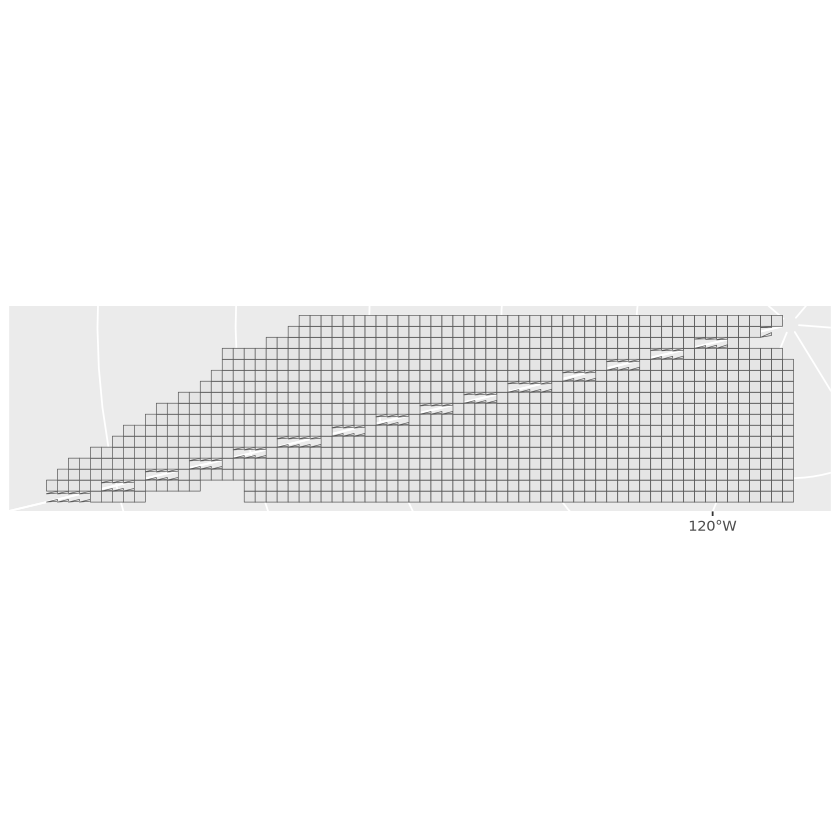

In [15]:
ggplot() + geom_sf(data=tiles)